In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# read the necessary data
rawdata = pd.read_csv('./data/clean/clean_data.csv')
# convert the date column to datetime format
# format="mixed" parses each value independently (the column mixes dd/mm/yyyy and
# dd/mm/yy, e.g. some days in Oct-Dec 2024 use a 2-digit year); inferring a single
# format for the whole column would silently coerce mismatched rows to NaT and drop
# them in the groupby below.
rawdata["DATE"] = pd.to_datetime(rawdata["DATE"], format="mixed", dayfirst=True, errors='coerce')
# turn all column into numeric, except the date  and heure columns
for col in rawdata.columns:
    if col not in ['DATE', 'HEURE']:
        rawdata[col] = pd.to_numeric(rawdata[col], errors='coerce')

# replace Heure values by categories
# 8h00 is the morning, 10h30 or 10h00 is midday, 14h00 or 15h30 is the afternoon.
def categorize_heure(heure):
    if pd.isna(heure):
        return np.nan
    else:
        heure = str(heure).strip()  # Remove any leading/trailing whitespace
        if heure in ['8h00', '8h30']:
            return 'morning'
        elif heure in ['10h00', '10h30']:
            return 'midday'
        elif heure in ['14h00', '15h00', '15h30']:
            return 'afternoon'
        else:
            return 'unknown'
rawdata['HEURE'] = rawdata['HEURE'].apply(categorize_heure)

# avergae the values of the same day
avgdata = rawdata.drop(columns=['HEURE']).groupby('DATE').mean().reset_index()

## Distributed water (exit)

In [3]:
# select column that have EX in their name
EX_data = avgdata[['DATE'] + [col for col in avgdata.columns if 'EX' in col]]
EX_data.head()

,DATE,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
0,2024-01-01,7.040000,18.800000,289.000000,144.500000,1.1,0.01
1,2024-01-02,6.973333,18.266667,285.333333,142.666667,1.0,0.01
2,2024-01-03,6.943333,18.300000,267.666667,133.500000,1.0,0.01
3,2024-01-04,7.020000,17.466667,317.666667,158.833333,1.0,0.01
4,2024-01-05,NaN,NaN,NaN,NaN,NaN,NaN


#### Descriptive Statistics

In [4]:
EX_data.describe()

,DATE,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
count,346,319.000000,318.000000,319.000000,319.000000,313.000000,319.000000
mean,2024-07-06 00:00:00,7.900825,20.724565,432.721552,237.221296,0.952838,0.054911
min,2024-01-01 00:00:00,6.693333,15.700000,212.400000,116.820000,0.200000,0.000000
25%,2024-03-29 06:00:00,7.371667,17.900000,321.333333,176.991667,0.900000,0.000000
50%,2024-06-29 12:00:00,8.120000,20.200000,413.000000,228.800000,1.000000,0.000000
75%,2024-09-29 18:00:00,8.265000,23.475000,500.500000,281.600000,1.000000,0.070000
max,2025-01-31 00:00:00,8.480000,27.700000,789.000000,433.950000,2.150000,0.650000
std,NaN,0.498526,3.106521,123.858945,70.632937,0.133723,0.101936


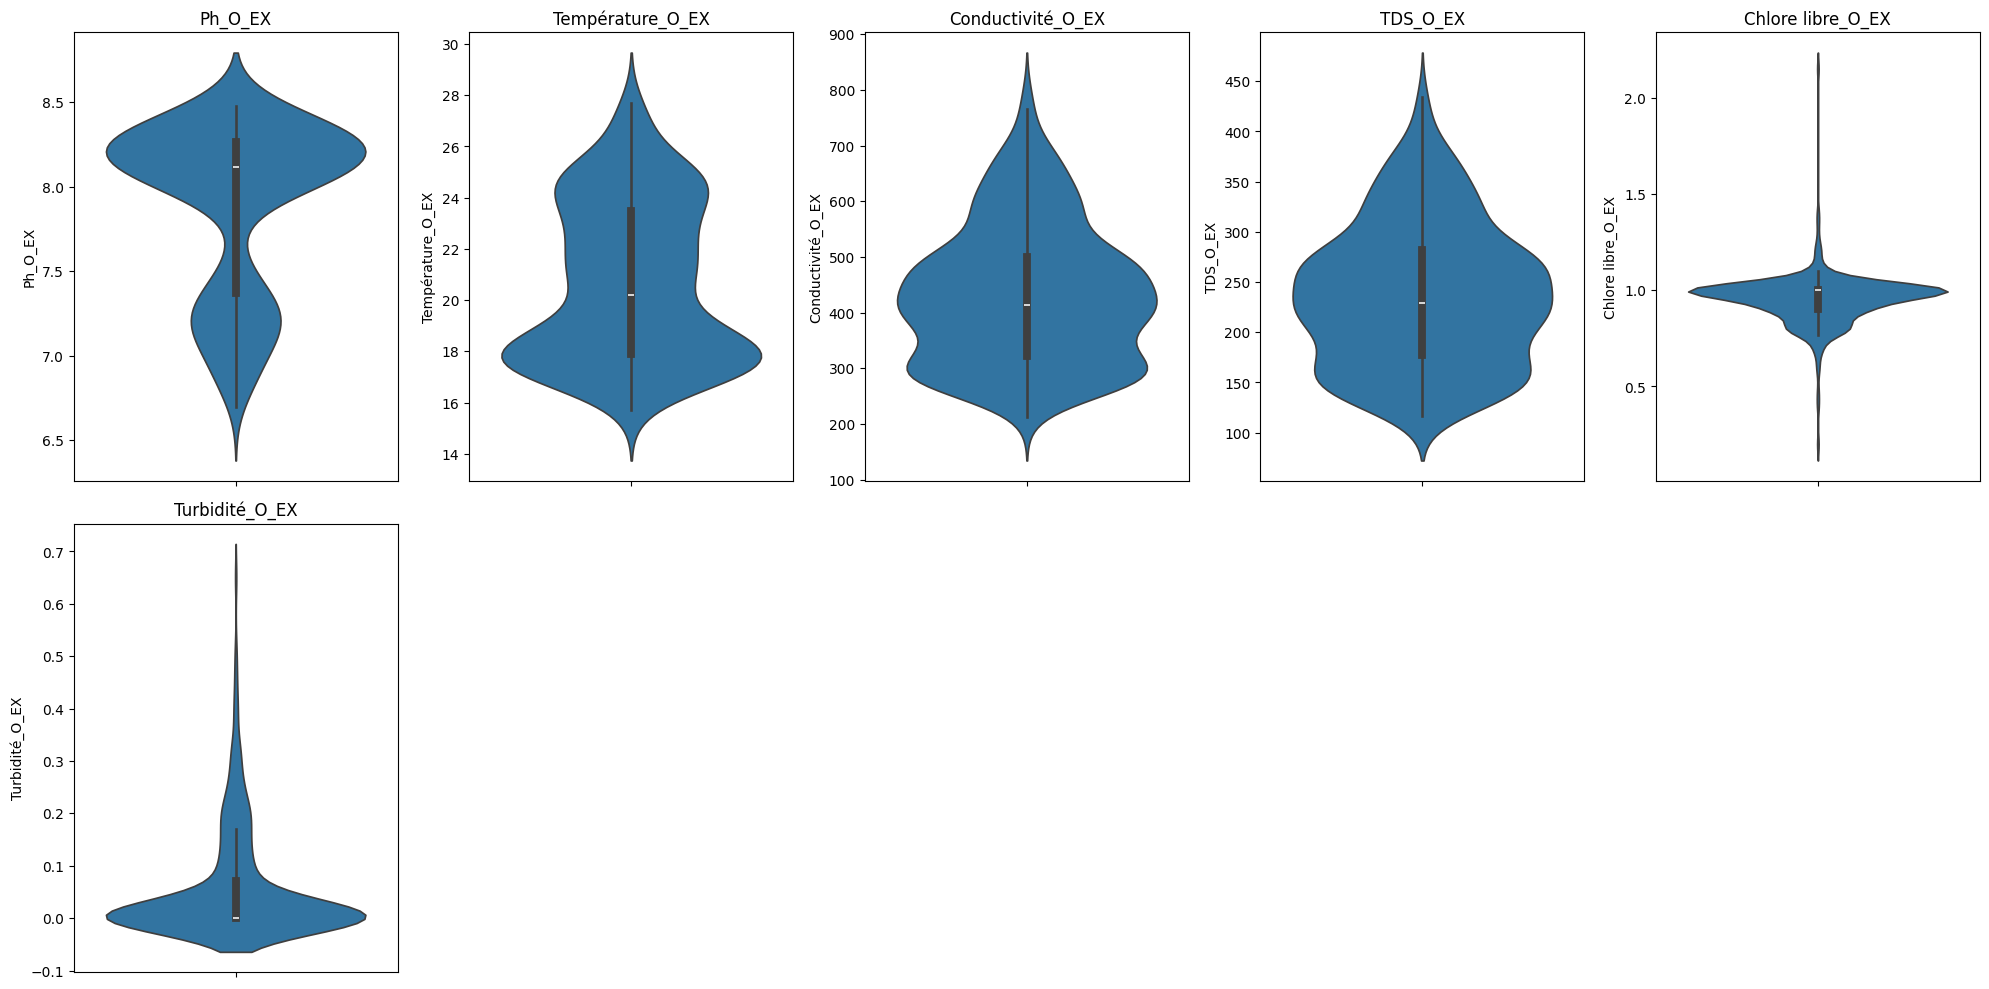

In [5]:
# boxplot of EX data
n_cols = 5
n_rows = -(-((len(EX_data.columns) - 1)) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, EX_data.columns[1:]):
    sns.violinplot(y=EX_data[col], ax=ax)
    ax.set_title(col)
for ax in axes[len(EX_data.columns) - 1:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

#### Temporal Evolution of the data

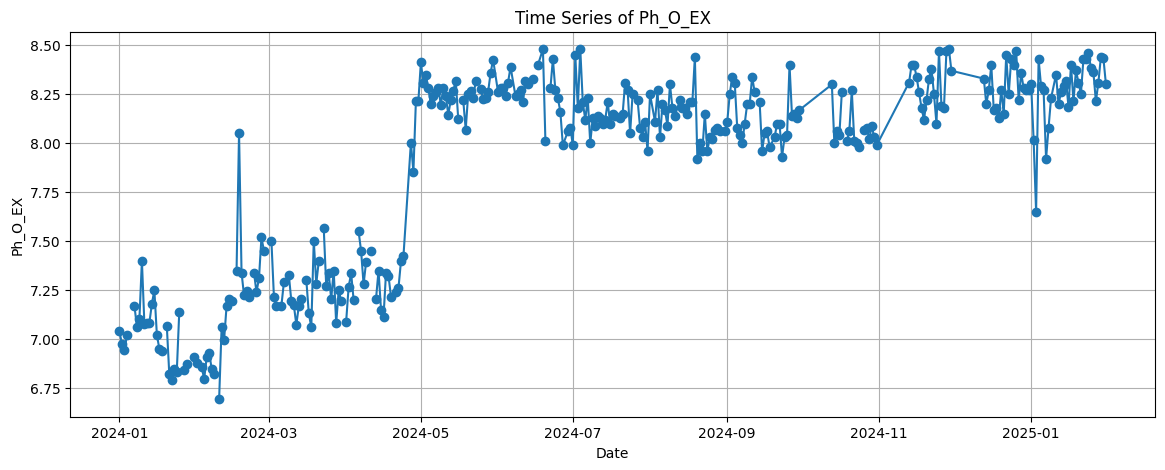

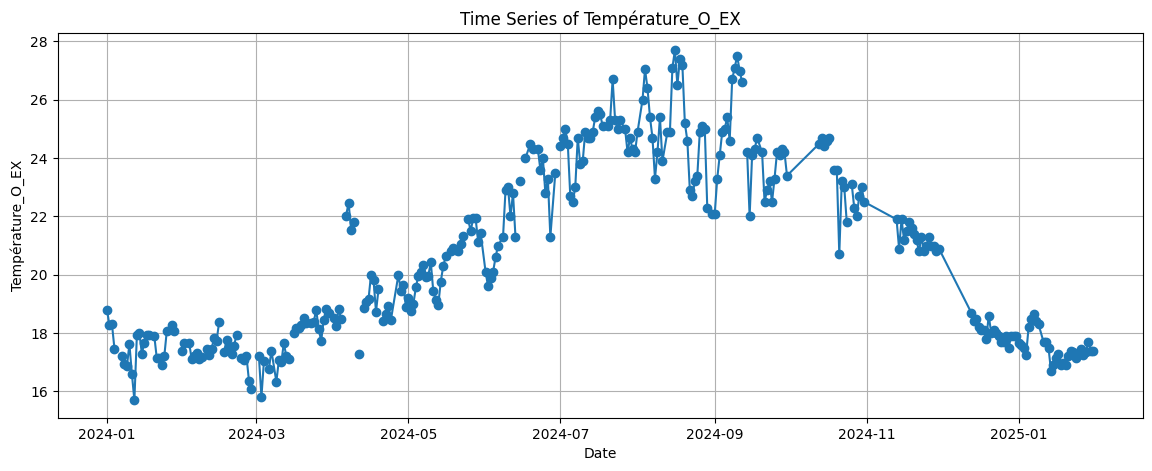

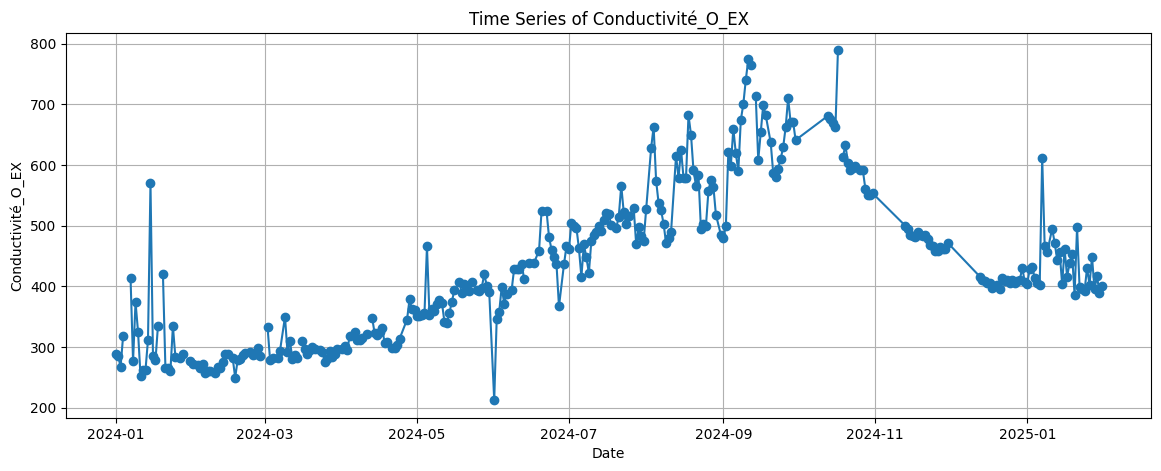

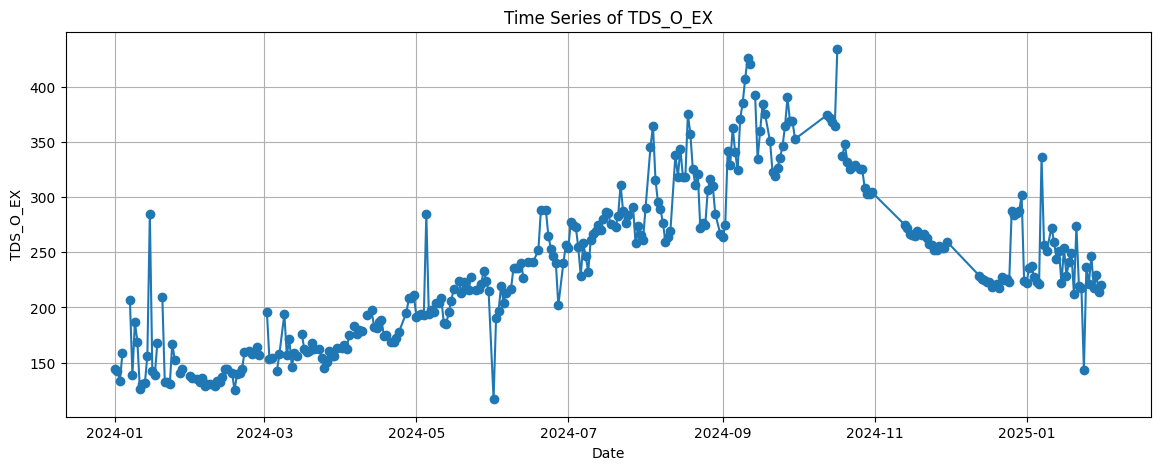

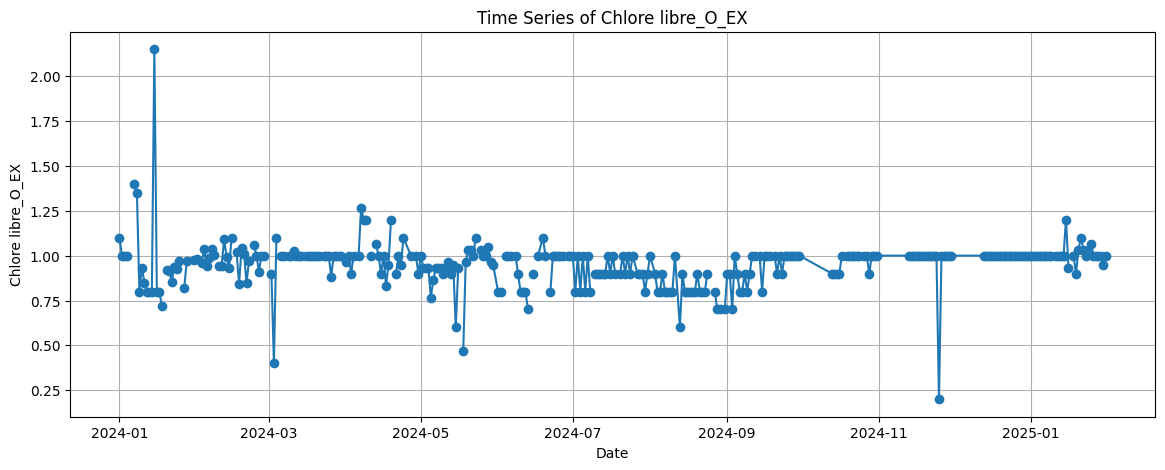

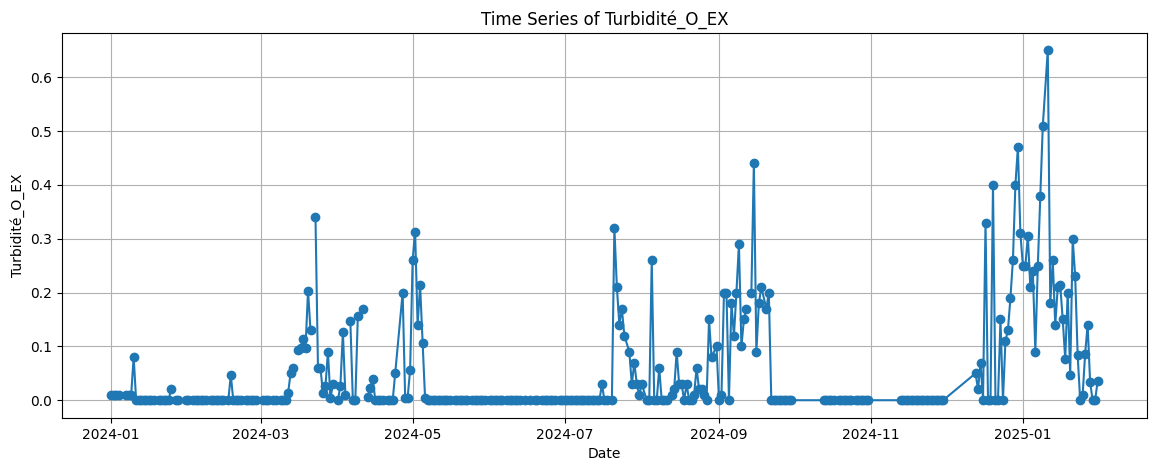

In [6]:
for col in EX_data.columns:
    if col != 'DATE':
        plt.figure(figsize=(14, 5))
        plt.plot(EX_data['DATE'], EX_data[col], marker='o')
        plt.title(f'Time Series of {col}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.grid()
        plt.show()

#### Visualtion of the relationship between variables

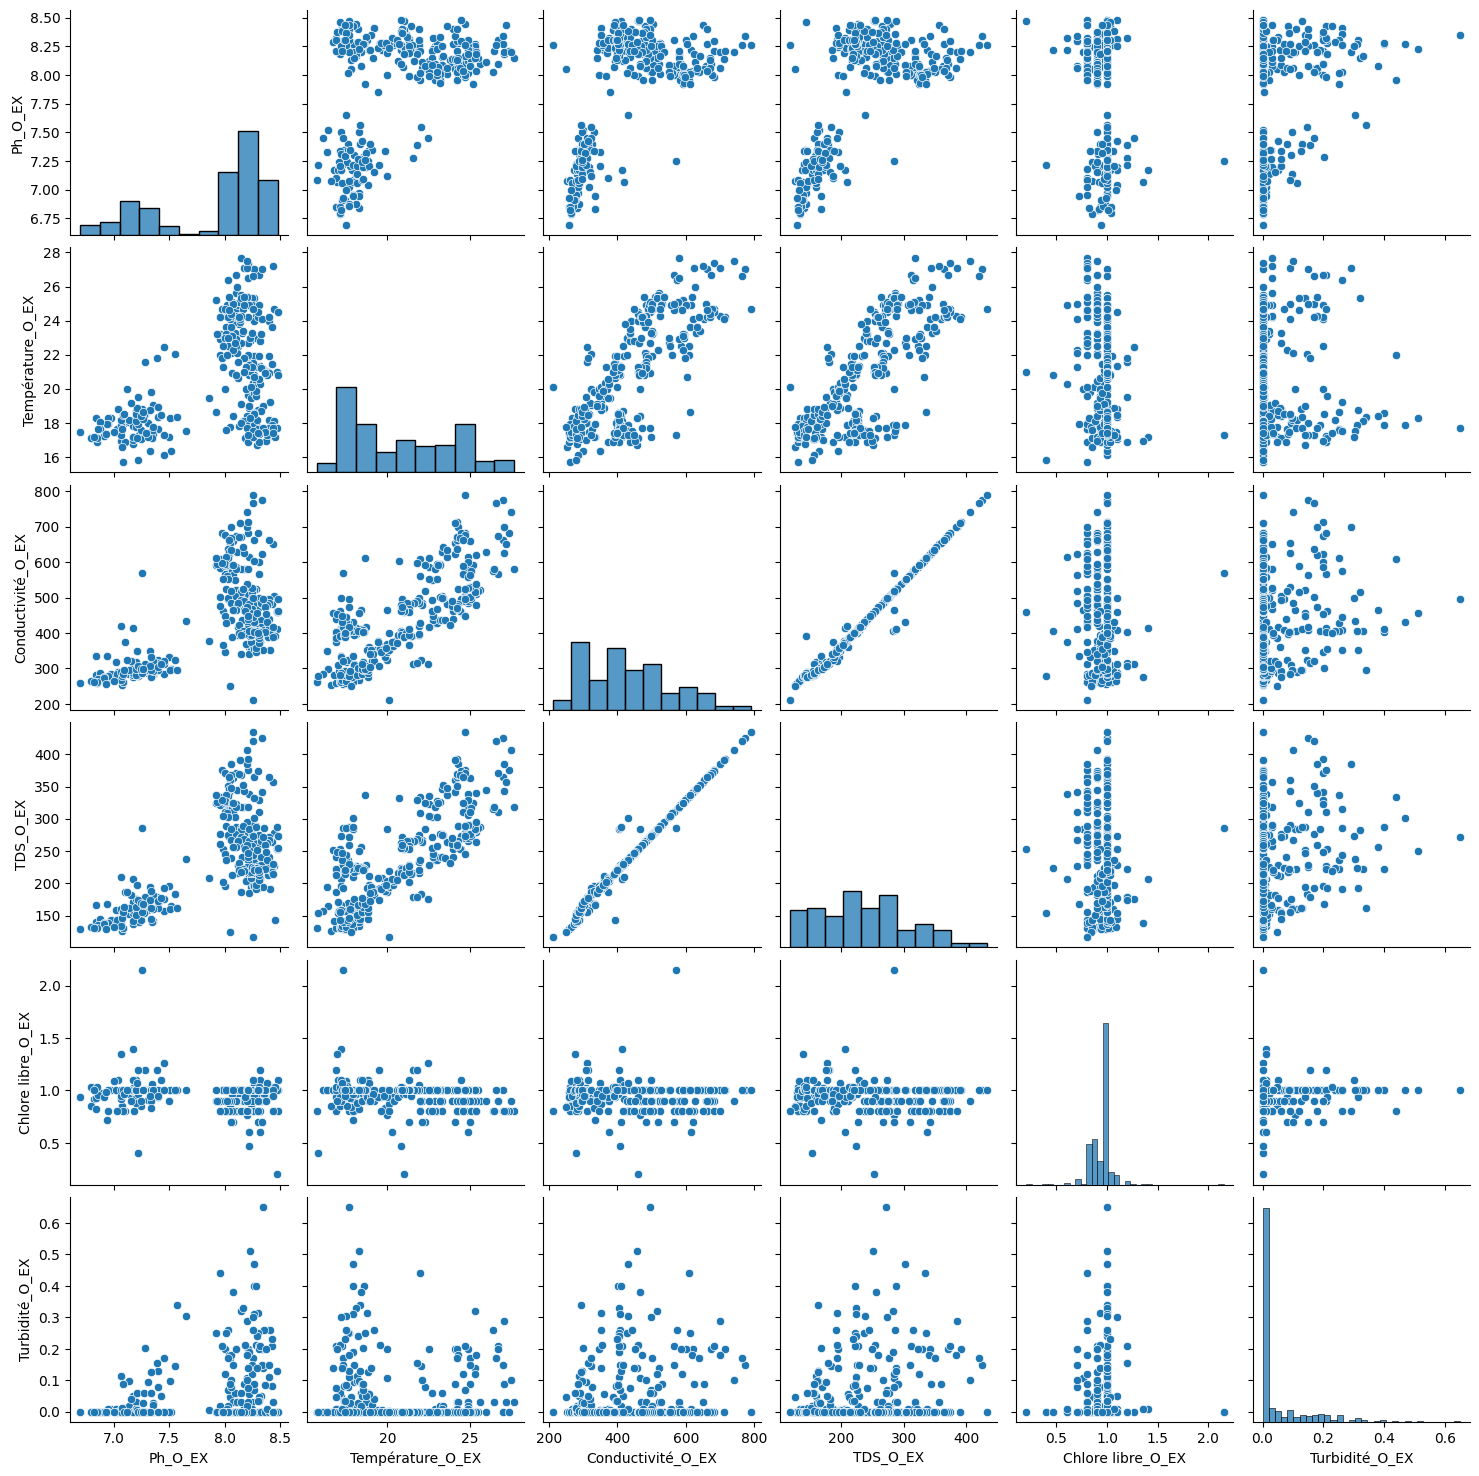

In [7]:
sns.pairplot(EX_data.iloc[:, 1:])

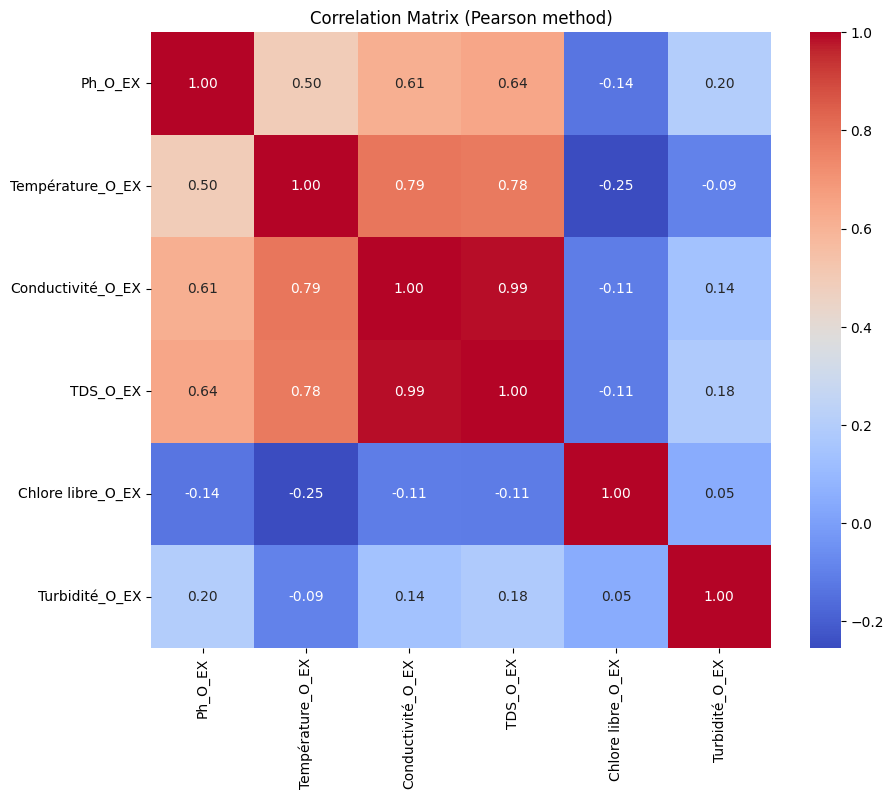

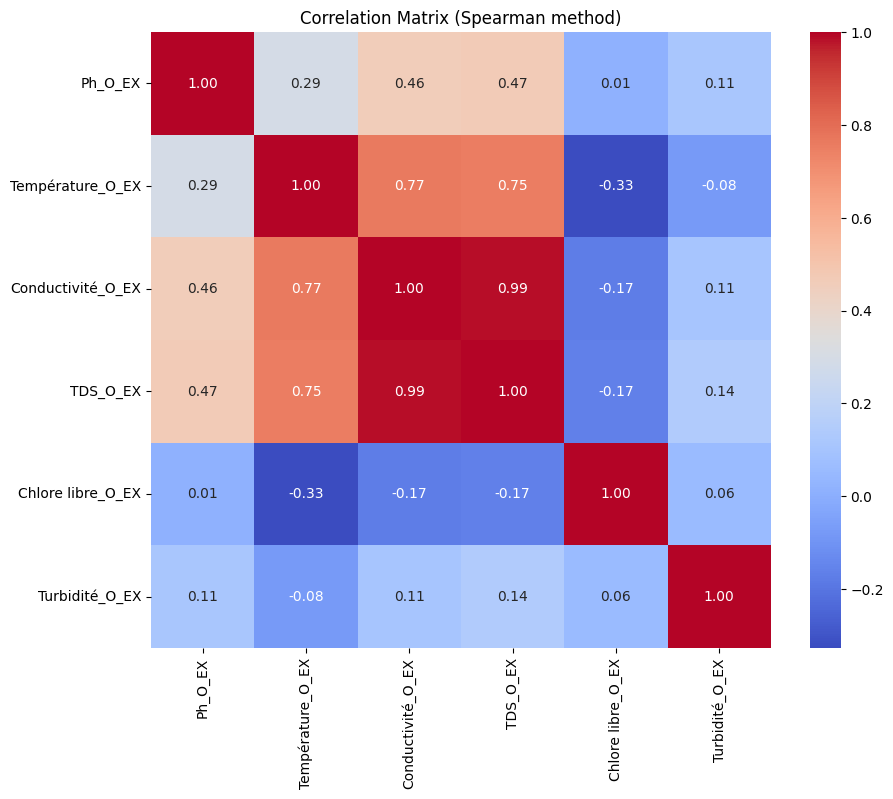

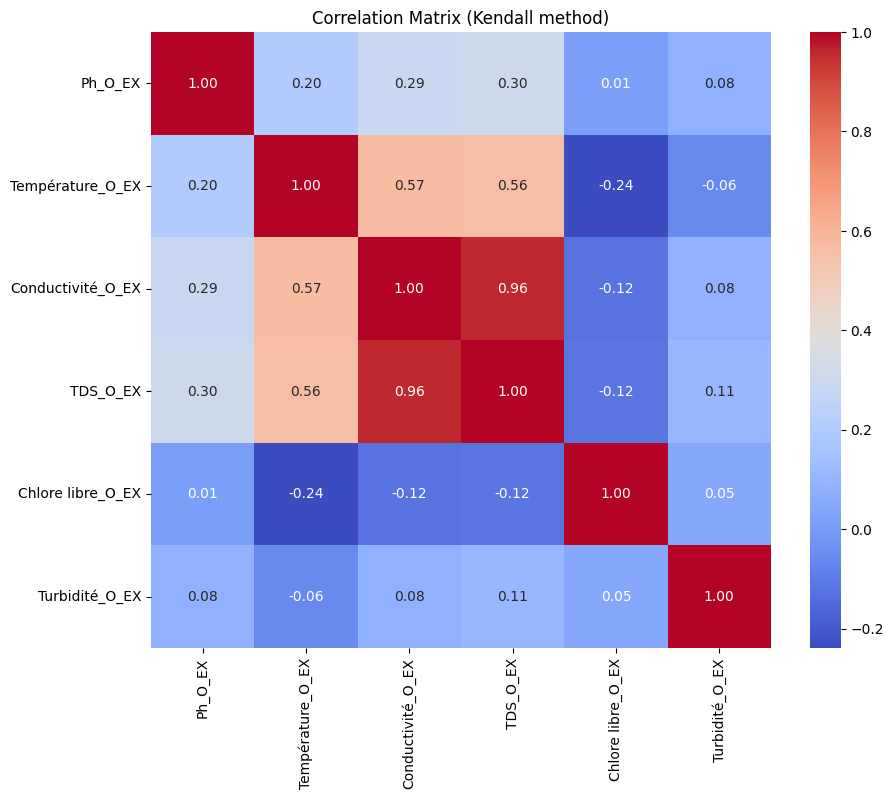

In [8]:
# calculate the correlation matrix using Pearson correlation, spearman correlation, and Kendall correlation
correlation_methods = ['pearson', 'spearman', 'kendall']
for method in correlation_methods:
    corr_matrix = EX_data.iloc[:, 1:].corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix ({method.capitalize()} method)')
    plt.show()

#### Time series features analysis

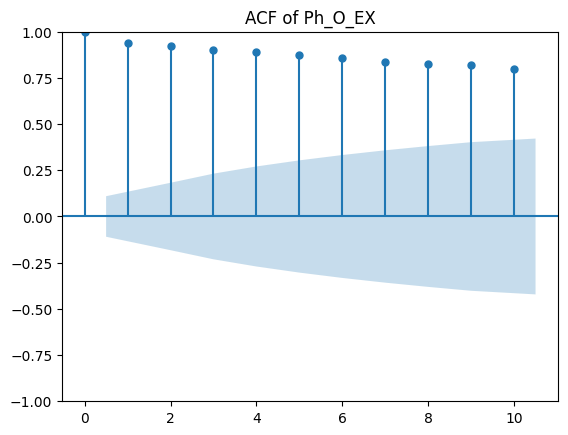

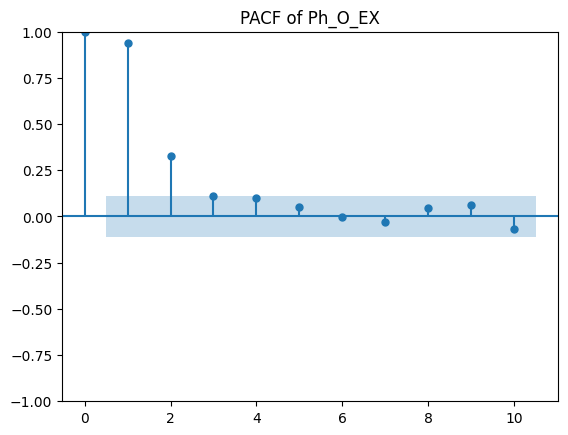

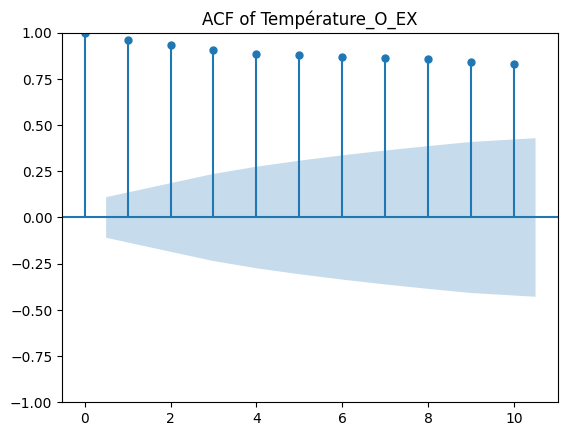

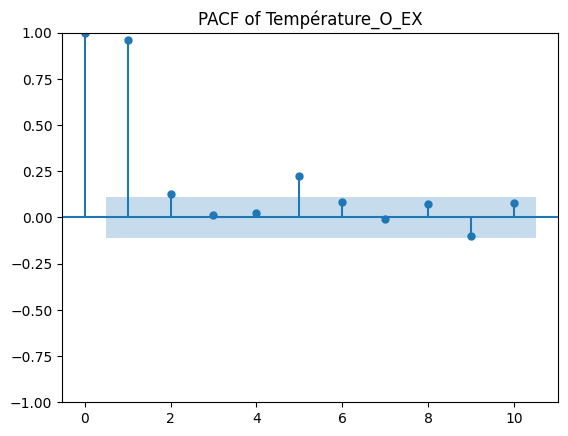

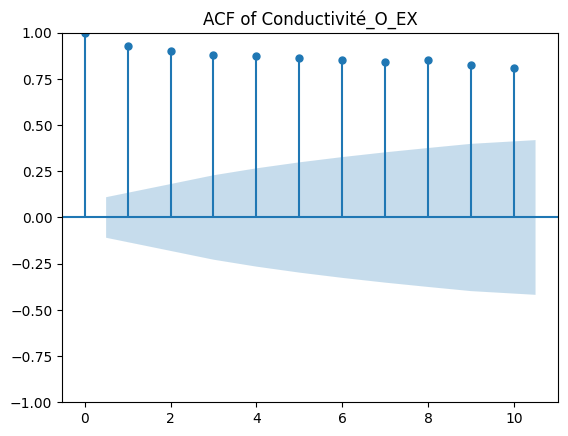

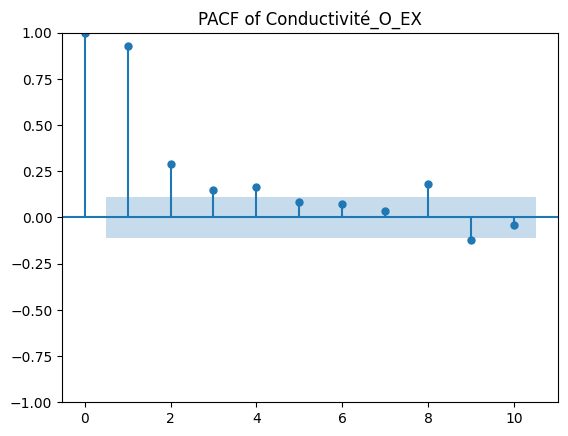

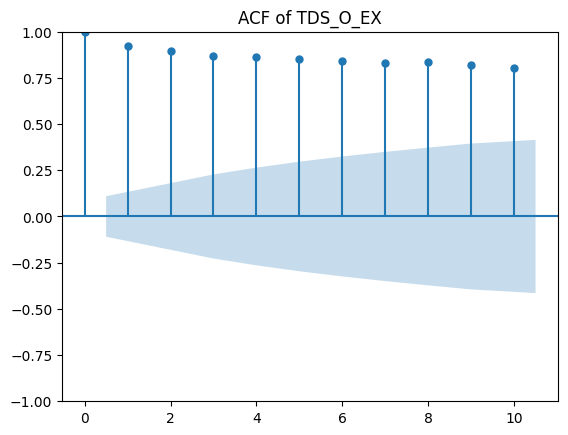

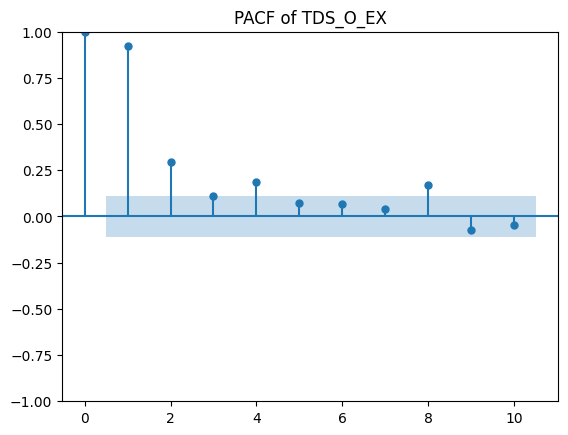

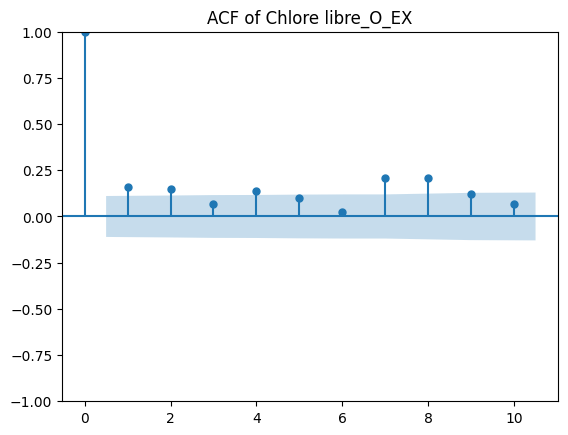

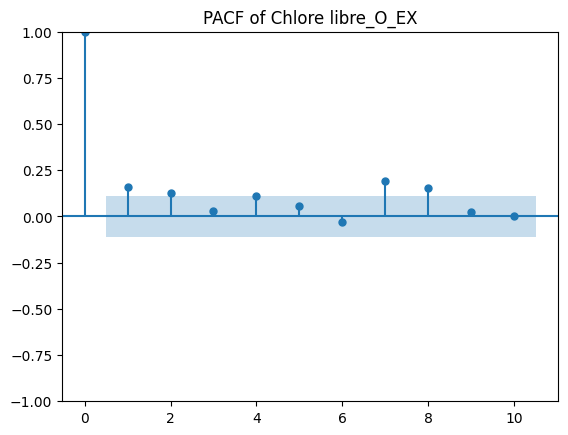

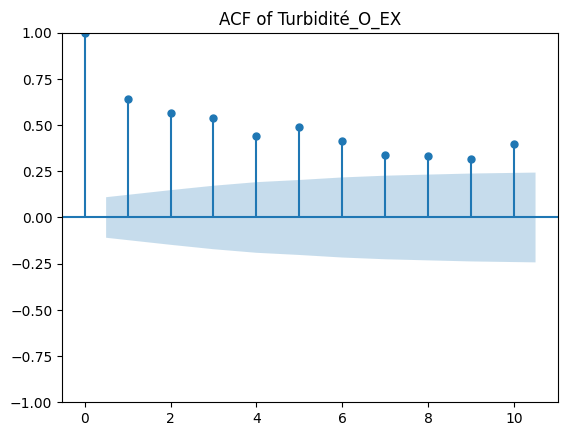

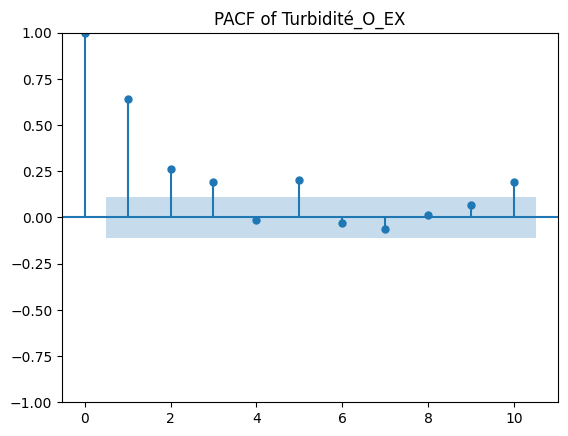

In [9]:
# ACF and PACF for each EX variable
for col in EX_data.columns[1:]:
    plot_acf(EX_data[col].dropna(), lags=10)
    plt.title(f'ACF of {col}')
    plt.show()

    plot_pacf(EX_data[col].dropna(), lags=10)
    plt.title(f'PACF of {col}')
    plt.show()

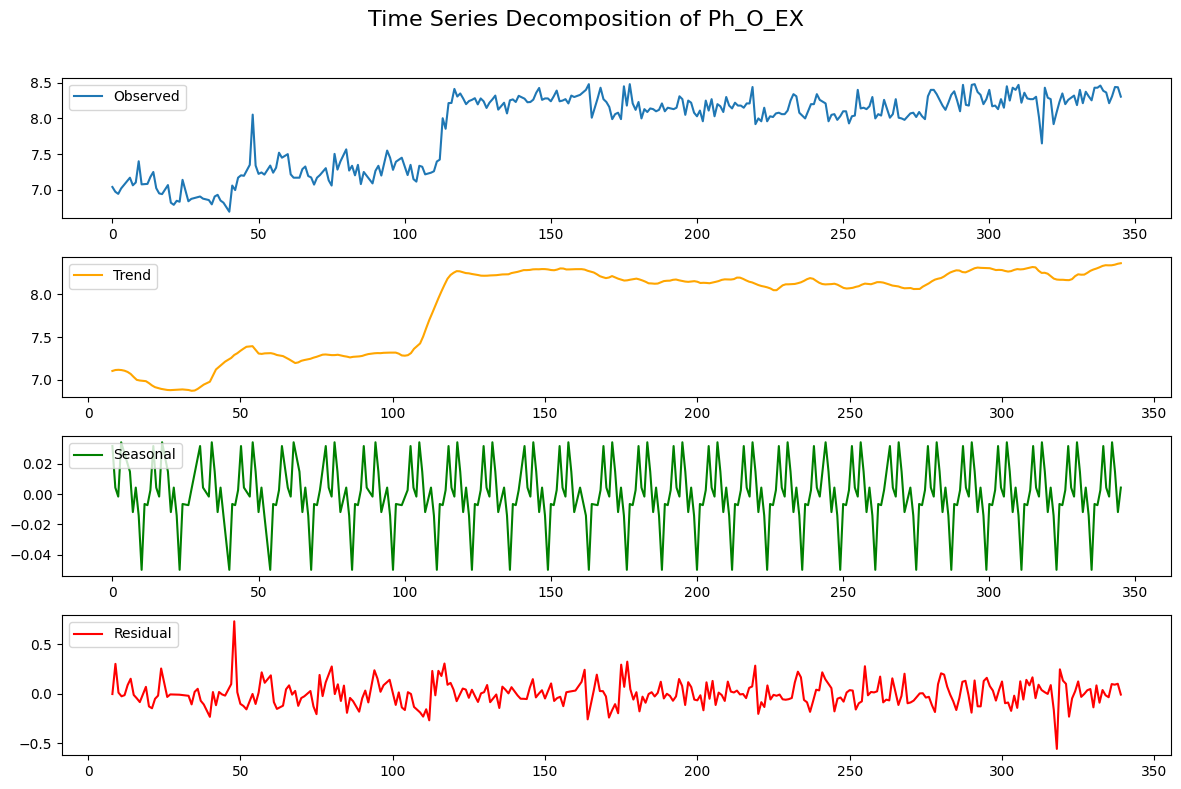

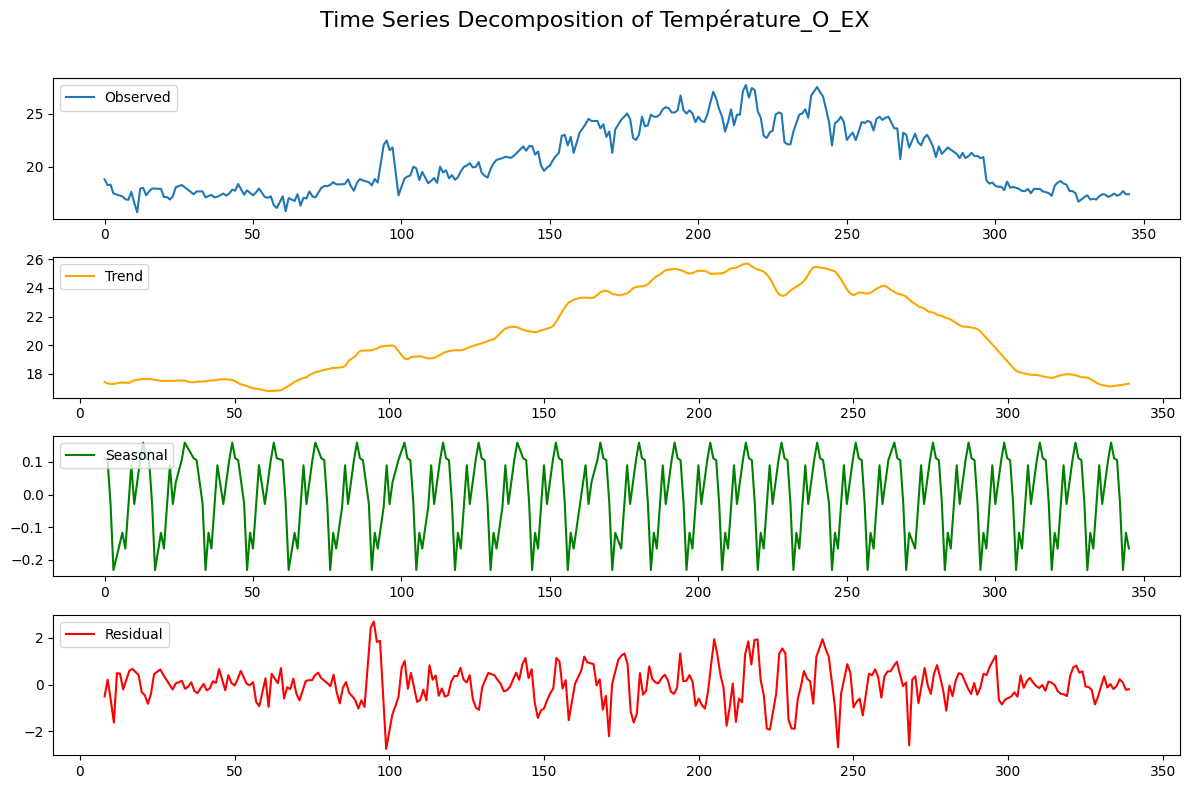

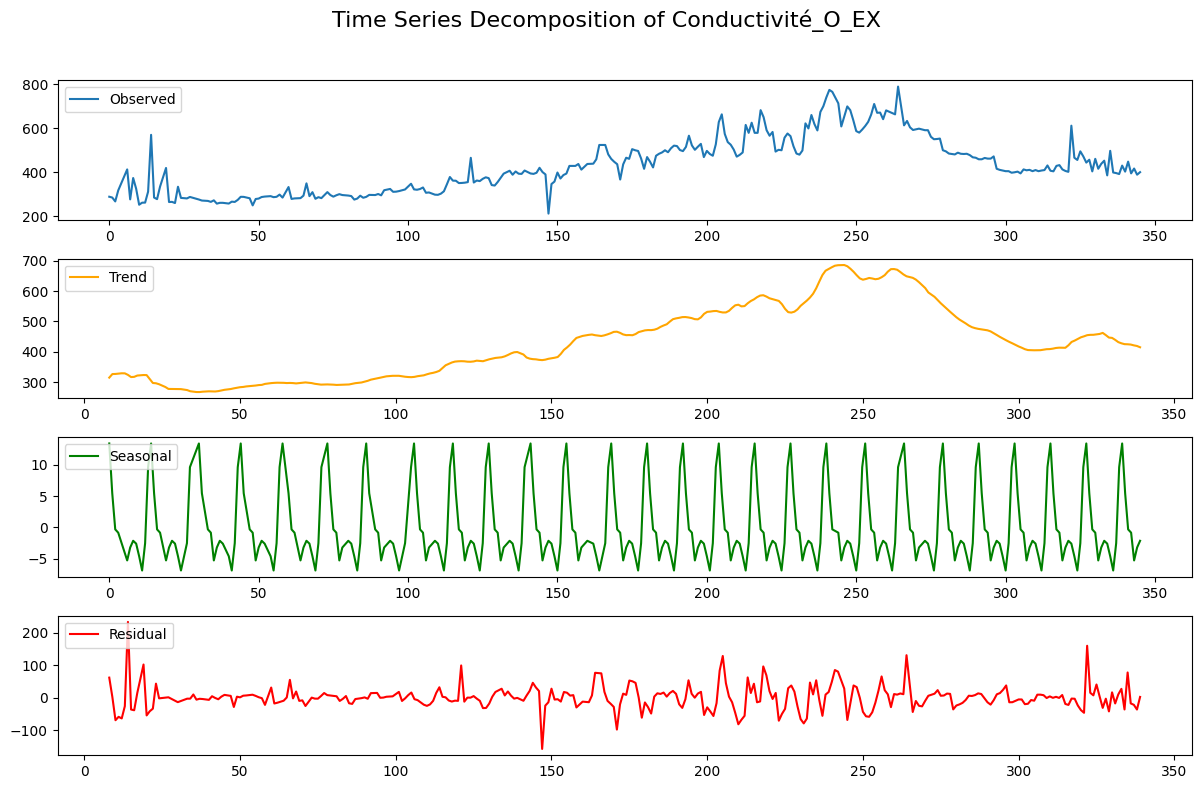

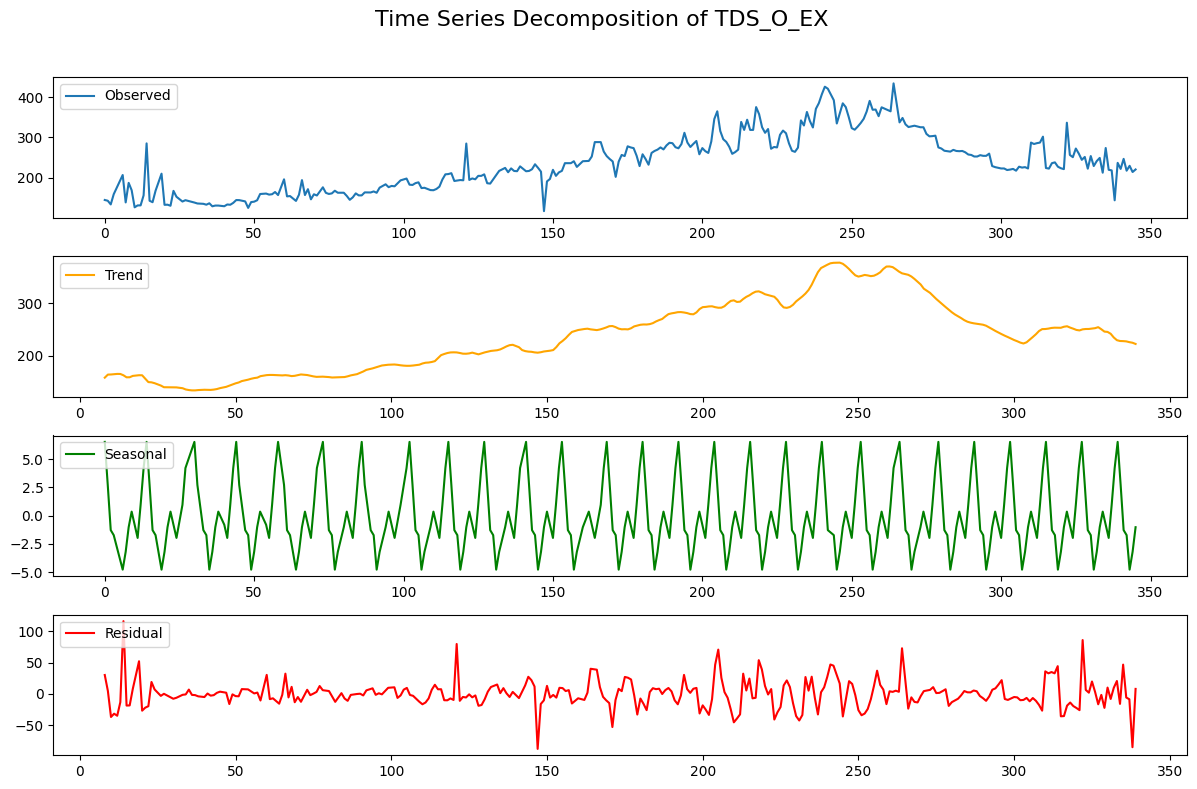

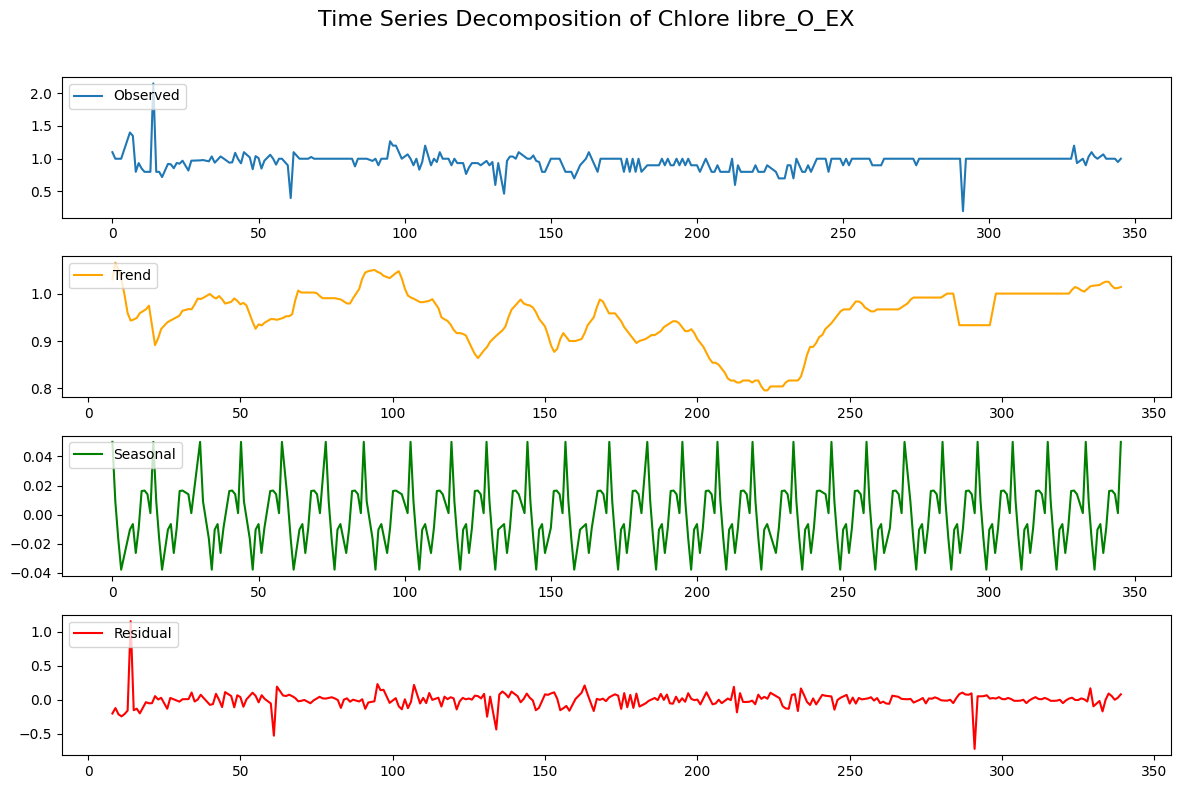

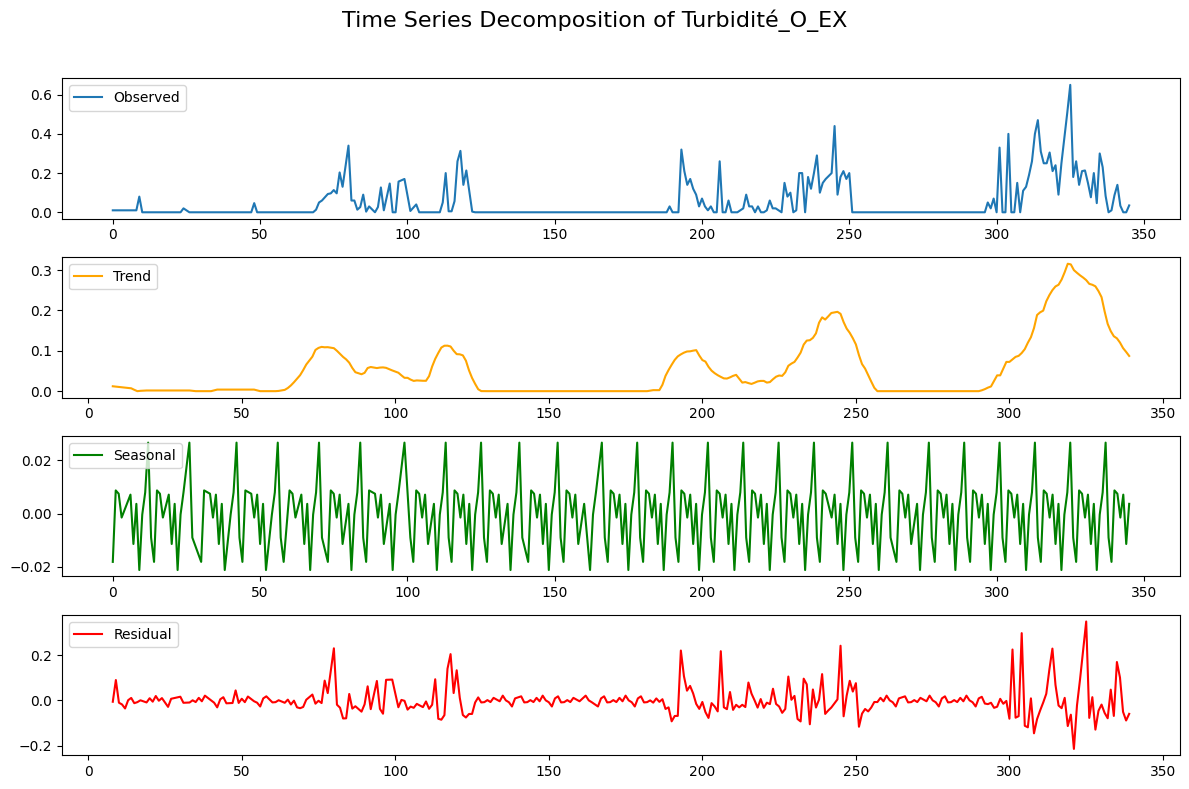

In [10]:
# time series decomposition for each EX variable

for col in EX_data.columns[1:]:
    decomp = seasonal_decompose(EX_data[col].dropna(), model='additive', period=12)
    plt.figure(figsize=(12, 8))
    plt.suptitle(f'Time Series Decomposition of {col}', fontsize=16)
    plt.subplot(411)
    plt.plot(decomp.observed, label='Observed')
    plt.legend(loc='upper left')
    plt.subplot(412)
    plt.plot(decomp.trend, label='Trend', color='orange')
    plt.legend(loc='upper left')
    plt.subplot(413)
    plt.plot(decomp.seasonal, label='Seasonal', color='green')
    plt.legend(loc='upper left')
    plt.subplot(414)
    plt.plot(decomp.resid, label='Residual', color='red')
    plt.legend(loc='upper left')
    plt.tight_layout(rect=[0, 0, 1, 0.96])